<a href="https://colab.research.google.com/github/vidaltiburciodominguez-boop/Analisis-ConnectaTel/blob/main/DAE_Stori.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

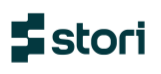
#`Stori DAE Take Home Test 2025`
⚠️ Note: Please try to complete this test without relying on AI tools such as ChatGPT or Copilot. We’re interested in evaluating your own problem-solving and analytical skills.
---



In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Step 1. Load the data into a pandas data frame
#### In the e-mail where you received this test, you will find 2 attached files named: `cc_transactions.csv` and `cc_cards.csv`

Please upload both CSV files to your Google Colab environment.
By default, Colab creates a folder named sample_data, make sure to upload the CSV files into the same parent folder (outside of sample_data) so they can be easily accessed

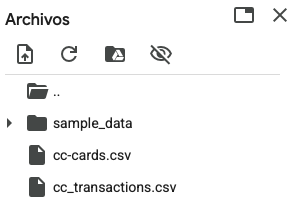

In [ ]:
#Make sure you can now read the csv's as data frames
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

df_transactions = pd.read_csv('/content/cc_transactions.csv')
df_cards = pd.read_csv('/content/cc_cards.csv')
df_transactions.head()


,transaction_date,transaction_id,account,card,merchant_name,mcc_code,txn_type,txn_amt,txn_status,decline_reason,posted_date
0,2025-07-06 01:45:20,c559d43a434cb0aa4a88dc78176ecc8d,cfdfba94560dd22522b9674781eec13c,5fbda9b22365be1e00f57b62ccbfa4e6,Google Ellation,7372,PURCHASE,119.00,REJECT,The card status is DISABLED,NaN
1,2025-07-06 17:13:40,15819569196abe161c342127db599d8a,278ce67793c26a4b23d9c1a5a86a65ac,0aab49c6e43c80c8c0ea262d1432d488,10291 STRV COSMOPOL,5621,PURCHASE,449.00,POSTED,NaN,2025-07-07
2,2025-07-06 16:41:32,8b656e31325c49210868ef5e7a9a5a91,f0470ba82c0fb09e65b33b5ca45c8de8,ea9fc704fc82574b1281438abeb50574,MI ATT A APP PS,4814,PURCHASE,1462.25,POSTED,NaN,2025-07-08
3,2025-07-06 17:38:21,b47ce07521dbe5773abd2f7e22a285b4,c0b4a281651d170cde8a1d4efb8d9b3d,f4ec50239f6d233c38ec07bb97469c71,DLO*RAPPI,5814,PURCHASE,11.75,POSTED,NaN,2025-07-08
4,2025-07-06 15:47:07,5e5f478bc9c62131521071614463fd4a,4acdb95a80c4c889b87aad46ab9906d1,03a32f08e16799076eb44b7cb5f738ba,Google Max Stream HBO,5734,PURCHASE,199.00,REJECT,DQ bucket 3,NaN


# Step 2. Exploratory Data Analysis
Now that you have successfully loaded the data it is time to start doing an Exploratory Data Anlaysis, the objective of this step is for you to understand the type of variables, number of columns, number of rows etc.

TIP. You can Join both df using card column

Add as many cells as you need to record your findings.


---



In [ ]:
# Join the DataFrames using how=left to mantain all transactions and add the information about the cards
df_enriched_transactions= df_transactions.merge(df_cards, how='left', on='card')
# Data structure and type verification (EDA)
df_enriched_transactions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12406 entries, 0 to 12405
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   transaction_date  12406 non-null  object 
 1   transaction_id    12406 non-null  object 
 2   account           12406 non-null  object 
 3   card              12406 non-null  object 
 4   merchant_name     12406 non-null  object 
 5   mcc_code          12406 non-null  int64  
 6   txn_type          12406 non-null  object 
 7   txn_amt           12406 non-null  float64
 8   txn_status        12406 non-null  object 
 9   decline_reason    2722 non-null   object 
 10  posted_date       9684 non-null   object 
 11  card_type         12406 non-null  object 
 12  created_tms       12406 non-null  object 
dtypes: float64(1), int64(1), object(11)
memory usage: 1.2+ MB



I will describe the insights from this dataset, which consists of **12,406** records.

1.- The `decline_reason` column represents **22%** of the records, suggesting that **2,722** transactions were rejected. This opens a line of investigation to identify fraud or credit limit issues.

2.- The column `posted_date` has a discrepancy of **9,684** records, approximately **2,722** transactions without a post date. These most likely correspond exactly to the rejected transactions. Failed transactions are usually not posted on the final statement.

3.-Data Formatting Issues (Dtypes)
To perform time series calculations and graphs, the following needs to be corrected. The `transaction_date`, `published_date`, and `created_tms` columns appear as objects (text). I won't be able to calculate "days elapsed" until I must convert them to datetime format.

**Dataset description**

`transaction_date` — Date the original transaction was made.

`transaction_id` — Unique identifier for each transaction record.

`account` — Account number associated with the customer.

`card` — Identifier or number of the card used.

`Merchant_name` — Name of the merchant where the purchase was made.

`mcc_code` — Merchant category code.

`txn_type` — Transaction type (e.g., purchase, return).

`txn_amt` — Monetary amount of the transaction.

`txn_status` — Transaction status (e.g., approved or declined).

`decade_reason` — Specific reason the transaction was declined (if applicable).

`posted_date` — Official date the transaction was posted to the statement.

`card_type` — Card category or type (e.g., Credit, Debit).

`create_tms` — Timestamp of the creation of the record in the system.




In [ ]:
#Convert date columns to datetime format
date_columns=['transaction_date','posted_date','created_tms']
for col in date_columns:
    df_enriched_transactions[col]=pd.to_datetime(df_enriched_transactions[col], errors='coerce')

#Ensure the amount is a floating-point number (in case there is any hidden text)
df_enriched_transactions['txn_amt']=pd.to_numeric(df_enriched_transactions['txn_amt'], errors='coerce')

#Checking changes
df_enriched_transactions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12406 entries, 0 to 12405
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   transaction_date  12406 non-null  datetime64[ns]
 1   transaction_id    12406 non-null  object        
 2   account           12406 non-null  object        
 3   card              12406 non-null  object        
 4   merchant_name     12406 non-null  object        
 5   mcc_code          12406 non-null  int64         
 6   txn_type          12406 non-null  object        
 7   txn_amt           12406 non-null  float64       
 8   txn_status        12406 non-null  object        
 9   decline_reason    2722 non-null   object        
 10  posted_date       9684 non-null   datetime64[ns]
 11  card_type         12406 non-null  object        
 12  created_tms       12396 non-null  datetime64[ns]
dtypes: datetime64[ns](3), float64(1), int64(1), object(8)
memory usage: 1.2+ MB


In [ ]:
#  Count the unique transaction_ids
total_uniques = df_enriched_transactions['transaction_id'].nunique()

# Get the total number of rows in the dataset
total_rows = len(df_enriched_transactions)

# Compare and display results
print(f"Unique values ​​in transaction_id: {total_uniques}")
print(f"Total number of rows in the dataset: {total_rows}")

if total_uniques == total_rows:
    print("\n Validation successful! No duplicate IDs.")
else:
    print(f"\n Warning! There are {total_rows - total_uniques} duplicate records.")

Unique values ​​in transaction_id: 10000
Total number of rows in the dataset: 12406

 Warning! There are 2406 duplicate records.


The dataset has **2,406** duplicates out of **12,406** rows, meaning almost **19%** of the data is repeated.

This changes things: if this isn't cleaned up, any monetary sums or transaction counts will be inflated and inaccurate.

Why did this happen?
The error most likely occurred during the merge process. If the same card number appears twice in the cards file `df_cards` by mistake, when merging it with the transactions, Pandas duplicates each transaction row to match both card entries.

How to fix it? (Deep cleaning)
The viable option is to remove these duplicates to keep only the unique data before proceeding.

In [ ]:
#  Remove duplicates based on the transaction ID, keeping only the first occurrence

df_enriched_transactions = df_enriched_transactions.drop_duplicates(subset=['transaction_id'], keep='first')

# Revalidate

total_uniques = df_enriched_transactions['transaction_id'].nunique()
total_rows = len(df_enriched_transactions)

print(f"New total rows: {total_rows}")
print(f"Do the numbers match now?: {total_uniques == total_rows}")

New total rows: 10000
Do the numbers match now?: True


In [ ]:
#Validate changes
df_enriched_transactions.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10000 entries, 0 to 12405
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   transaction_date  10000 non-null  datetime64[ns]
 1   transaction_id    10000 non-null  object        
 2   account           10000 non-null  object        
 3   card              10000 non-null  object        
 4   merchant_name     10000 non-null  object        
 5   mcc_code          10000 non-null  int64         
 6   txn_type          10000 non-null  object        
 7   txn_amt           10000 non-null  float64       
 8   txn_status        10000 non-null  object        
 9   decline_reason    2481 non-null   object        
 10  posted_date       7519 non-null   datetime64[ns]
 11  card_type         10000 non-null  object        
 12  created_tms       9992 non-null   datetime64[ns]
dtypes: datetime64[ns](3), float64(1), int64(1), object(8)
memory usage: 1.1+ MB


**Exploring numeric columns of dataset**

In [ ]:
# Descriptive statistics of numeric variables
print(df_enriched_transactions[['txn_amt']].describe())


            txn_amt
count  10000.000000
mean     427.612706
std      849.178138
min        0.000000
25%       82.000000
50%      184.000000
75%      422.685000
max    21000.000000


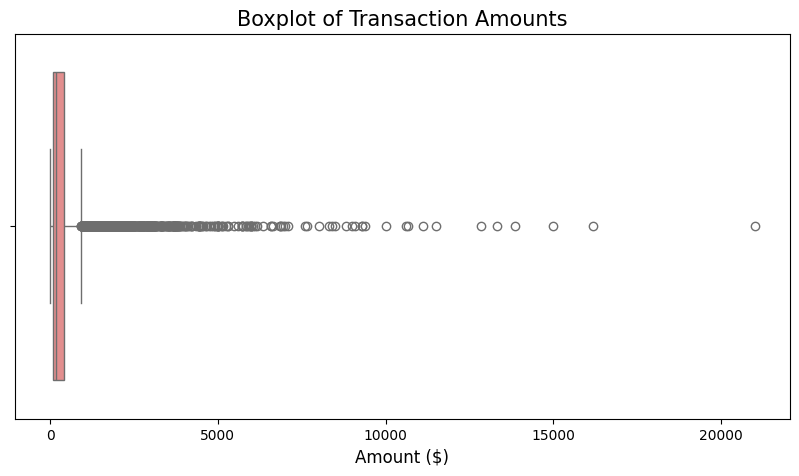

In [ ]:
# Create the boxplot to visually detect outliers
plt.figure(figsize=(10, 5))
sns.boxplot(x=df_enriched_transactions['txn_amt'], color='lightcoral')

# Customization
plt.title('Boxplot of Transaction Amounts', fontsize=15)
plt.xlabel('Amount ($)', fontsize=12)

plt.show()

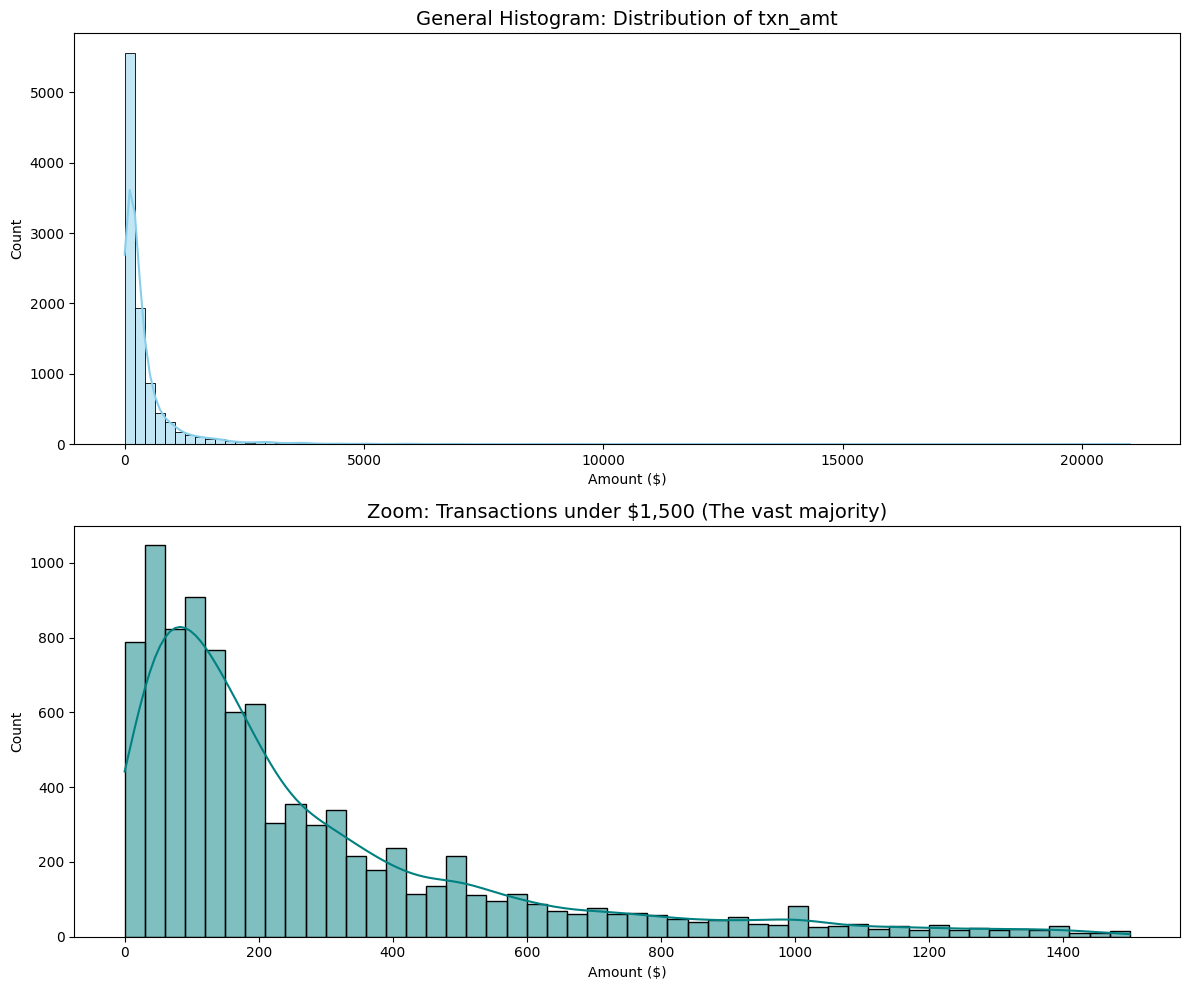

In [ ]:
# Configure to display two graphs in the same image
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

# 1. General Histogram (To see the impact of outliers)
sns.histplot(df_enriched_transactions['txn_amt'], bins=100, kde=True, color='skyblue', ax=ax1)
ax1.set_title('General Histogram: Distribution of txn_amt', fontsize=14)
ax1.set_xlabel('Amount ($)')

# 2. Zoomed Histogram (To see the actual behavior of the majority)
# I visually filter down to $1,500, which is where the "whisker" of the boxplot
sns.histplot(df_enriched_transactions[df_enriched_transactions['txn_amt'] < 1500]['txn_amt'],
             bins=50, kde=True, color='teal', ax=ax2)
ax2.set_title('Zoom: Transactions under $1,500 (The vast majority)', fontsize=14)
ax2.set_xlabel('Amount ($)')

plt.tight_layout()
plt.show()

Diagnosis of `txn_amt` column.

1.- **Presence of extreme outliers**: There is a massive gap between the 75th percentile and  the maximum value **\$21,000**.

This  indicates that 75% of the users spend less than **\$423**, but there are isolated transactions  exceeding  **\$20,000**.
These latter transactions are "outliers" that inflate the average.


2.- **Data Dispersion (Volatility)**: The standard deviation **\$849.17** is double the average **\$427.61**.

This means that spending behavior is highly inconsistent: you have everything from minimal transactions to high-value purchases, making the "average" an unreliable measure for representing the typical user.


3.- **Anomaly in the Lower Bound**: The minimum value of **\$0.00 **is a cause for concern. This typically represents card validation attempts (when an app checks if the card is valid) or registration errors that could skew the results if left unaddressed.


4.- **Distribution Bias**: Because the maximum value is so high, the data distribution is skewed to the right (positive skew). Most of your data is clustered around small amounts, with a very long tail of expensive purchases.




**Exploring categorical columns of dataset**

In [ ]:
# List of categorical columns to validate
categorical_cols = ['card_type', 'txn_status', 'txn_type', 'decline_reason']

print("--- Unique Values Validation ---\n")

for col in categorical_cols:
    unique_vals = df_enriched_transactions[col].unique()
    num_unique = df_enriched_transactions[col].nunique()

    print(f"Column: {col}")
    print(f"Number of unique values: {num_unique}")
    print(f"Values: {unique_vals}")
    print("-" * 30)

--- Unique Values Validation ---

Column: card_type
Number of unique values: 2
Values: ['PHYSICAL' 'VIRTUAL']
------------------------------
Column: txn_status
Number of unique values: 2
Values: ['REJECT' 'POSTED']
------------------------------
Column: txn_type
Number of unique values: 1
Values: ['PURCHASE']
------------------------------
Column: decline_reason
Number of unique values: 38
Values: ['The card status is DISABLED' nan 'DQ bucket 3' 'DQ15-29'
 'The credit line is insufficient' 'IsoDTIScoreAlert' 'DQ bucket 2'
 'MerchantNameInBlackList' 'Customer block' 'The CVV does not match'
 'MerchantIdNameInBlackList' 'CountryMccInBlockList'
 'MerchantIdInBlackList' 'EcommerceManualNoCvvBlock'
 'no active msi contract for the merchant' 'MerchantClusterD7L2B2Count'
 'Pending Closure(account)' 'ecommerceTransactionD1L2ByMerchant1dCount'
 'MerchantIdInBlockList' 'ecommerceTransaction5mCount'
 'The expiration date received does not match the card'
 'MerchantNameInBlockList' 'The card statu

**Quality Diagnosis and Unique Values** :

`card_type`: There are  2 values ​​('PHYSICAL', 'VIRTUAL'). These are perfect and requires no further cleaning.

`txn_status`: There are only 2 statuses ('REJECT', 'POSTED'). This greatly simplifies future classification models.

`txn_type`: There is one unique value: 'PURCHASE'.
 Since there are no other types (such as 'REFUND' or 'TRANSFER'), this column does not provide information for differentiating groups, but it confirms that the entire dataset is about purchases.

`decline_reason`:
There are 38 unique rejection reasons. This is where the business detail lies.

The value nan (not a number) appears. This is normal because transactions that were approved (POSTED) have no reason to be rejected, so they remain empty.

There are a variety range from user errors to complex security rules ('fraudTemporaryReject', 'The PIN is incorrect',  'virtualGamblingMccTransaction1dCount', etc).

In [ ]:
# Checking categorical columns
# 1. List of essential categorical variables
categorical_columns = ['card_type', 'txn_status', 'txn_type']

# 2. Loop to display frequencies for each category
for col in categorical_columns:
    print(f"\n--- {col.replace('_', ' ').title()} Frequency ---")
    print(df_enriched_transactions[col].value_counts())
    print("-" * 35)

# 3. Specific analysis for Top 10 Merchants
print("\n--- Top 10 Merchants (by volume) ---")
print(df_enriched_transactions['merchant_name'].value_counts().head(10))


--- Card Type Frequency ---
card_type
PHYSICAL    7686
VIRTUAL     2314
Name: count, dtype: int64
-----------------------------------

--- Txn Status Frequency ---
txn_status
POSTED    7519
REJECT    2481
Name: count, dtype: int64
-----------------------------------

--- Txn Type Frequency ---
txn_type
PURCHASE    10000
Name: count, dtype: int64
-----------------------------------

--- Top 10 Merchants (by volume) ---
merchant_name
UBER* TRIP               357
APPLE.COM/BILL           325
Google One               202
DLO*DIDI RIDES           168
AMAZON MX                130
UBER* EATS               117
D LOCAL*REST DIDIFOOD    114
Google Amazon Mobile      72
UBER* PENDING             70
Google YouTube            65
Name: count, dtype: int64


/tmp/ipython-input-223/2046144108.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_enriched_transactions, x='card_type', palette='viridis', ax=axes[0])
/tmp/ipython-input-223/2046144108.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_enriched_transactions, x='txn_status', palette='magma', ax=axes[1])


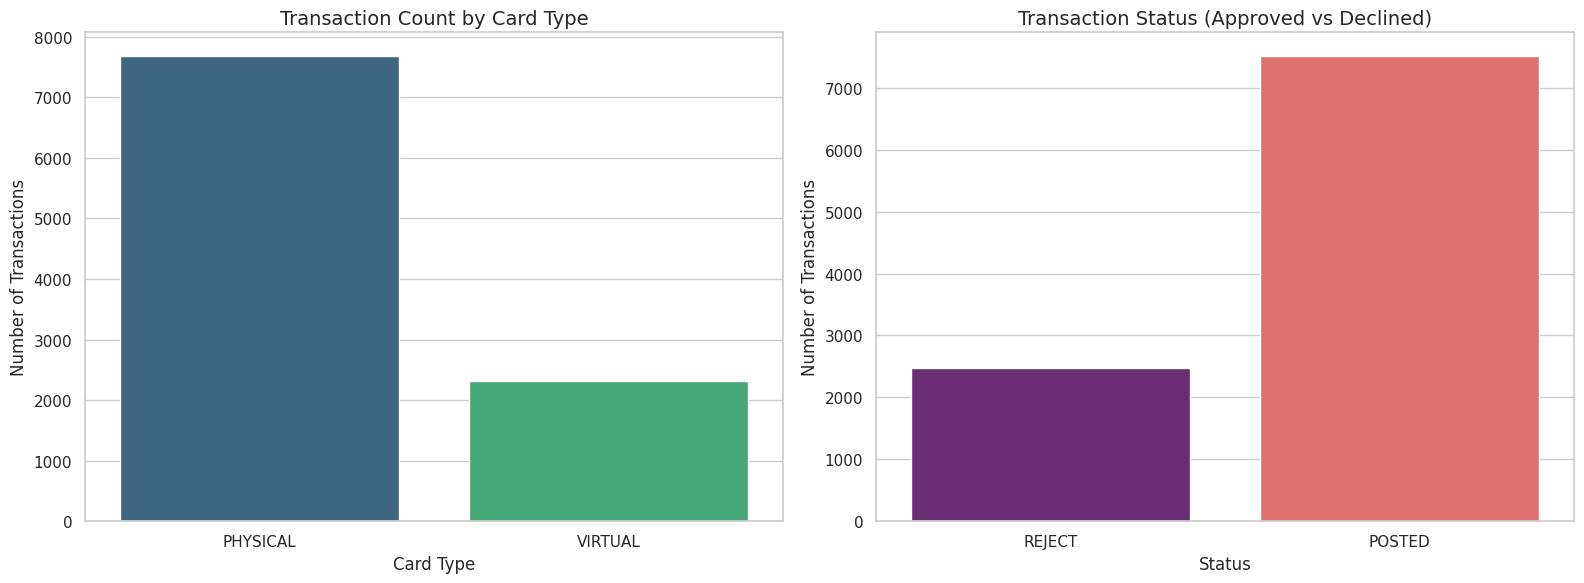

In [ ]:
# Set visual style
sns.set_theme(style="whitegrid")

# Create a figure with subplots for the categorical variables
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Card Type Distribution
sns.countplot(data=df_enriched_transactions, x='card_type', palette='viridis', ax=axes[0])
axes[0].set_title('Transaction Count by Card Type', fontsize=14)
axes[0].set_xlabel('Card Type')
axes[0].set_ylabel('Number of Transactions')

# Plot 2: Transaction Status
sns.countplot(data=df_enriched_transactions, x='txn_status', palette='magma', ax=axes[1])
axes[1].set_title('Transaction Status (Approved vs Declined)', fontsize=14)
axes[1].set_xlabel('Status')
axes[1].set_ylabel('Number of Transactions')

plt.tight_layout()
plt.show()

***Categorical Variables Diagnostic Report***
1. **Card Type Analysis**
  - Physical Dominance: The vast majority of transactions are performed using PHYSICAL cards (approx. 7,700) compared to VIRTUAL cards (approx. 2,300).

  - User Behavior: This suggests a strong preference for traditional in-person spending or that users primarily hold physical plastic for their daily needs.

2. **Transaction Status**

  - Success Rate: While most transactions are successfully POSTED, there is a  significant volume of REJECTED transactions (approx. 2,500).

  - Efficiency Metric: A rejection rate of roughly 25% is an important KPI to monitor. It indicates a need to investigate whether these are due to "Insufficient Funds," "Technical Errors," or "Fraud Prevention" triggers.

3. **Merchant Analysis**
  - The "Top 10 Merchants" list reveals that Stori users primarily use their cards for Digital Ecosystems and Urban Mobility:

  - Top Merchant: UBER* TRIP is the leading merchant by volume, showing the card is heavily used for transportation.

  - Digital Services: Significant activity is seen in APPLE.COM/BILL, Google One, Google Youtube, and Amazon MX.

  - Daily Needs: OXXO remains a top physical merchant, highlighting the card's role in "everyday" convenience purchases.

#Step 3.  It's Time to start answering some question
Remember: `Authorized transactions --> txn_status = POSTED `  

Add as many cells as you need

---



### Question 1. What percentage of all transactions were declined?
Calculate the percentage of declined transactions out of the total number of transactions. Present the result as a percentage (%).

In [ ]:
# Question 1. What is the % of declined transactions?
total_txns = len(df_enriched_transactions)
rejected_txns = len(df_enriched_transactions[df_enriched_transactions['txn_status'] == 'REJECT'])
rejection_percentage = (rejected_txns / total_txns) * 100
print(f"Q1. Overall Transaction Rejection Rate: {rejection_percentage:.2f}%")

Q1. Overall Transaction Rejection Rate: 24.81%


### Question 2. What is the most frequent decline reason and what percentage represent ?



In [ ]:
# Question 2. What is the most frequent decline reason and what percentage represent ?
decline_counts = df_enriched_transactions[df_enriched_transactions['txn_status'] == 'REJECT']['decline_reason'].value_counts()
top_reason = decline_counts.index[0]
top_reason_count = decline_counts.values[0]
top_reason_percentage = (top_reason_count / rejected_txns) * 100
print(f"Q2. Most Frequent Decline Reason: '{top_reason}'")
print(f"    (Accounting for {top_reason_percentage:.2f}% of all rejected transactions)")

Q2. Most Frequent Decline Reason: 'The credit line is insufficient'
    (Accounting for 50.75% of all rejected transactions)



### Question 3. What is the average authorized amount on virtual cards?




In [ ]:
# Question 3. What is the average authorized amount on virtual cards?
virtual_auth_avg = df_enriched_transactions[
    (df_enriched_transactions['card_type'] == 'VIRTUAL') &
    (df_enriched_transactions['txn_status'] == 'POSTED')
]['txn_amt'].mean()
print(f"Q3. Average Authorized Amount (Virtual Cards): ${virtual_auth_avg:.2f}")

Q3. Average Authorized Amount (Virtual Cards): $559.51



###Question 4. What is the largest transaction amount per merchant?


In [ ]:
# Question 4. What is the largest transaction amount per merchant?
max_amt_per_merchant = df_enriched_transactions.groupby('merchant_name')['txn_amt'].max().sort_values(ascending=False)
print("\nQ4. Top 5 Maximum Transaction Amounts by Merchant:")
print(max_amt_per_merchant.head(5).to_string())


Q4. Top 5 Maximum Transaction Amounts by Merchant:
merchant_name
ACURA LOMAS VERDES      21000.00
AEROMEXICO AV OL        16169.00
2074 EKT TEMOAYA        15000.00
GetYourGuide Tickets    13851.25
VIVA AEROBUS            13308.00


### Question 5. When was the last transaction on Amazon Mexico?

In [ ]:
# Question 5. When was the last transaction on Amazon Mexico?
df_enriched_transactions['transaction_date'] = pd.to_datetime(df_enriched_transactions['transaction_date'])
last_amazon_txn = df_enriched_transactions[df_enriched_transactions['merchant_name'] == 'AMAZON MX']['transaction_date'].max()
print(f"\nQ5. Timestamp of the Last Transaction at Amazon MX: {last_amazon_txn}")


Q5. Timestamp of the Last Transaction at Amazon MX: 2025-07-06 23:54:45


# Step 4. Let's go deeper

### At this point you have a better undestanding about the transactions data, now we what to understand our customers behavior



---



### Task 6. Add a new column that consecutively numbers each customers transactions, starting from 1 for each customerss most recent transaction.

The numbering should be partitioned by customers and sorted by transaction date in descending order (most recent to oldest).


In [ ]:
# Task 6. Add a new column that consecutively numbers each customers transactions, starting from 1 for each customerss most recent transaction.
# 1. Ensure the date column is in datetime format and sorted correctly
#Sort by 'account' and then by 'transaction_date' descending
df_enriched_transactions = df_enriched_transactions.sort_values(
    by=['account', 'transaction_date'],
    ascending=[True, False]
)

# 2. Create the new column 'transaction_rank'
# groupby('account') isolates each customer
# cumcount() numbers them starting from 0, so add 1
df_enriched_transactions['transaction_rank'] = df_enriched_transactions.groupby('account').cumcount() + 1

# 3. Verify the results for the first few customers
print("--- Transaction Numbering by Customer (Latest to Oldest) ---")
print(df_enriched_transactions[['account', 'transaction_date', 'transaction_rank']].head(10))

--- Transaction Numbering by Customer (Latest to Oldest) ---
                                account    transaction_date  transaction_rank
798    00053b3ae8bc82a62d4ceed370398196 2025-07-06 22:06:36                 1
2520   000e039c0a3559386b5f11ae0d98af3c 2025-07-06 09:05:16                 1
10923  00152e011909421da51c694fda9d94f6 2025-07-06 20:35:20                 1
3410   00152e011909421da51c694fda9d94f6 2025-07-06 13:32:06                 2
4462   0016e060aee85444a7807cb8d2c78f0a 2025-07-06 17:37:08                 1
7357   001e791654f795ba74cb93cc64bbcbfb 2025-07-06 18:39:36                 1
7033   002389ec536f3e785a964e19e6f4ac05 2025-07-06 14:37:18                 1
3264   002df5ffb13572e49d422882b89bd5fa 2025-07-06 14:55:44                 1
3814   0030bad4006a4714afe3c7423984377d 2025-07-06 18:07:26                 1
2065   00357c0c0b8eae090c7213519b6a6aeb 2025-07-06 14:11:07                 1


## Task 7. Add a column that shows the date of each user's previous transaction (i.e., the transaction immediately following it in chronological order).

Then, add another column that calculates the time difference in hours between the date of the current transaction and the previous transaction of that same user.

In [ ]:
# Task 7. Add a column that shows the date of each user's previous transaction (i.e., the transaction immediately following it in chronological order).
# 1. Sort the data: By account (A-Z) and date (Newest to Oldest)
# This order is crucial for the shift logic to work correctly
df_enriched_transactions = df_enriched_transactions.sort_values(
    by=['account', 'transaction_date'],
    ascending=[True, False]
)

# 2. Add 'previous_transaction_date'
# Since sorted Newest -> Oldest, the "previous" transaction in time is the row below (-1)
df_enriched_transactions['previous_transaction_date'] = (
    df_enriched_transactions.groupby('account')['transaction_date']
    .shift(-1)
)

# 3. Add 'time_diff_hours'
# Subtract the previous date from the current date and convert the result to hours
df_enriched_transactions['time_diff_hours'] = (
    df_enriched_transactions['transaction_date'] - df_enriched_transactions['previous_transaction_date']
).dt.total_seconds() / 3600

# --- Results Verification ---
print("--- Task 7: Time Difference Between Transactions ---")
cols_to_check = ['account', 'transaction_date', 'previous_transaction_date', 'time_diff_hours']
print(df_enriched_transactions[cols_to_check].head(10))

--- Task 7: Time Difference Between Transactions ---
                                account    transaction_date  \
798    00053b3ae8bc82a62d4ceed370398196 2025-07-06 22:06:36   
2520   000e039c0a3559386b5f11ae0d98af3c 2025-07-06 09:05:16   
10923  00152e011909421da51c694fda9d94f6 2025-07-06 20:35:20   
3410   00152e011909421da51c694fda9d94f6 2025-07-06 13:32:06   
4462   0016e060aee85444a7807cb8d2c78f0a 2025-07-06 17:37:08   
7357   001e791654f795ba74cb93cc64bbcbfb 2025-07-06 18:39:36   
7033   002389ec536f3e785a964e19e6f4ac05 2025-07-06 14:37:18   
3264   002df5ffb13572e49d422882b89bd5fa 2025-07-06 14:55:44   
3814   0030bad4006a4714afe3c7423984377d 2025-07-06 18:07:26   
2065   00357c0c0b8eae090c7213519b6a6aeb 2025-07-06 14:11:07   

      previous_transaction_date  time_diff_hours  
798                         NaT              NaN  
2520                        NaT              NaN  
10923       2025-07-06 13:32:06         7.053889  
3410                        NaT              NaN 

## Question 8. Is there a significant difference in the average time between approved and rejected transactions?
Calculate the time between each transaction and the previous one for each user. Then separate the results according to whether the transaction was approved or rejected, and compare the averages for each group.

In [ ]:
# Question 8. Is there a significant difference in the average time between approved and rejected transactions?
# 1. Calculate the average time difference for each status
avg_time_by_status = df_enriched_transactions.groupby('txn_status')['time_diff_hours'].mean()

# 2. Get specific values for comparison
avg_approved = avg_time_by_status.get('POSTED', 0)
avg_rejected = avg_time_by_status.get('REJECT', 0)
difference = abs(avg_approved - avg_rejected)

# --- Results Printing (English) ---
print("==================================================")
print("       TIME DIFFERENCE ANALYSIS BY STATUS         ")
print("==================================================\n")

print(f"Average time between Approved (POSTED) transactions: {avg_approved:.2f} hours")
print(f"Average time between Rejected (REJECT) transactions: {avg_rejected:.2f} hours")
print(f"\nAbsolute Difference: {difference:.2f} hours")

# Simple logic to define if it's significant (e.g., more than 1 hour difference)
if difference > 1:
    print("\nConclusion: YES, there is a significant difference in frequency.")
else:
    print("\nConclusion: NO, the time between transactions is similar for both statuses.")

       TIME DIFFERENCE ANALYSIS BY STATUS         

Average time between Approved (POSTED) transactions: 3.08 hours
Average time between Rejected (REJECT) transactions: 4.37 hours

Absolute Difference: 1.29 hours

Conclusion: YES, there is a significant difference in frequency.


## Task 9. Create two histograms showing the distribution of transaction amounts: one for approved transactions with Virtual Card and another for declined transactions with Virtual Card
Identify which transaction amounts are the most frequent in each group. Use appropriate binning and labeling in your visualization.


---



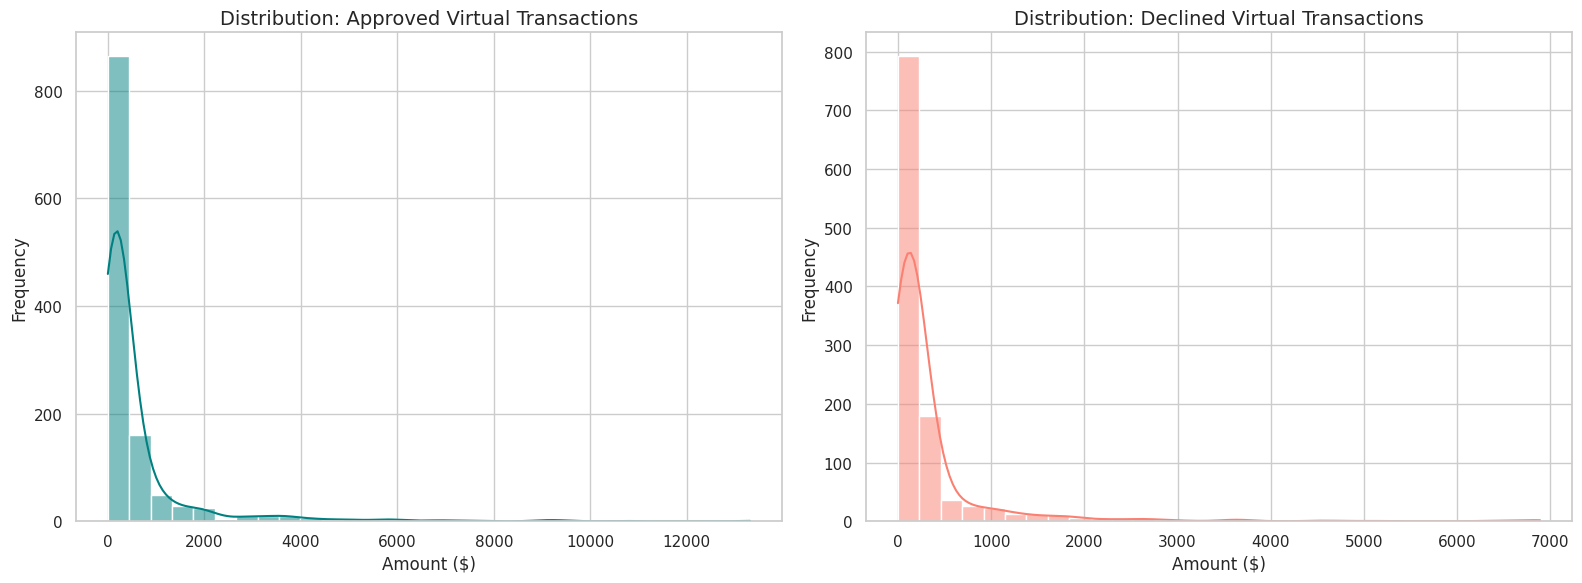

--- Peak Amount Analysis ---
The most frequent range for Approved Virtual Cards is: $0.90 - $444.47
The most frequent range for Declined Virtual Cards is: $0.00 - $229.65


In [ ]:
# 1. Filter the data for Virtual Cards
virtual_txns = df_enriched_transactions[df_enriched_transactions['card_type'] == 'VIRTUAL']

# 2. Split into Approved (POSTED) and Declined (REJECT)
approved_virtual = virtual_txns[virtual_txns['txn_status'] == 'POSTED']
declined_virtual = virtual_txns[virtual_txns['txn_status'] == 'REJECT']

# 3. Create the Visualizations
plt.figure(figsize=(16, 6))


# Histogram for Approved Virtual Transactions
plt.subplot(1, 2, 1)
sns.histplot(approved_virtual['txn_amt'], bins=30, kde=True, color='teal')
plt.title('Distribution: Approved Virtual Transactions', fontsize=14)
plt.xlabel('Amount ($)')
plt.ylabel('Frequency')

# Histogram for Declined Virtual Transactions
plt.subplot(1, 2, 2)
sns.histplot(declined_virtual['txn_amt'], bins=30, kde=True, color='salmon')
plt.title('Distribution: Declined Virtual Transactions', fontsize=14)
plt.xlabel('Amount ($)')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

# 4. Identify most frequent transaction amounts (Mode of the bins)
def get_peak_info(data, label):
    if not data.empty:
        # Calculate histogram bins
        counts, bin_edges = np.histogram(data, bins=30)
        max_bin_idx = np.argmax(counts)
        lower_edge = bin_edges[max_bin_idx]
        upper_edge = bin_edges[max_bin_idx + 1]
        print(f"The most frequent range for {label} is: ${lower_edge:.2f} - ${upper_edge:.2f}")
    else:
        print(f"No data available for {label}.")

print("--- Peak Amount Analysis ---")
get_peak_info(approved_virtual['txn_amt'], "Approved Virtual Cards")
get_peak_info(declined_virtual['txn_amt'], "Declined Virtual Cards")

# Step 5. Tell a Story
Now that you’ve analyzed the transaction behavior of our customers including decline reasons, merchants, and average time between transactions, it’s time to communicate your findings.

In this step, your goal is to create clear and compelling visualizations to share with non-technical stakeholders. Use charts to highlight key insights, patterns, or anomalies that help explain what’s happening and why it matters.

You can create as many visualizations as you need, and for each one, include a brief explanation or conclusion to help others understand its significance.

/tmp/ipython-input-223/1800107209.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_merchants.values, y=top_merchants.index, ax=axes[0,0], palette="viridis")


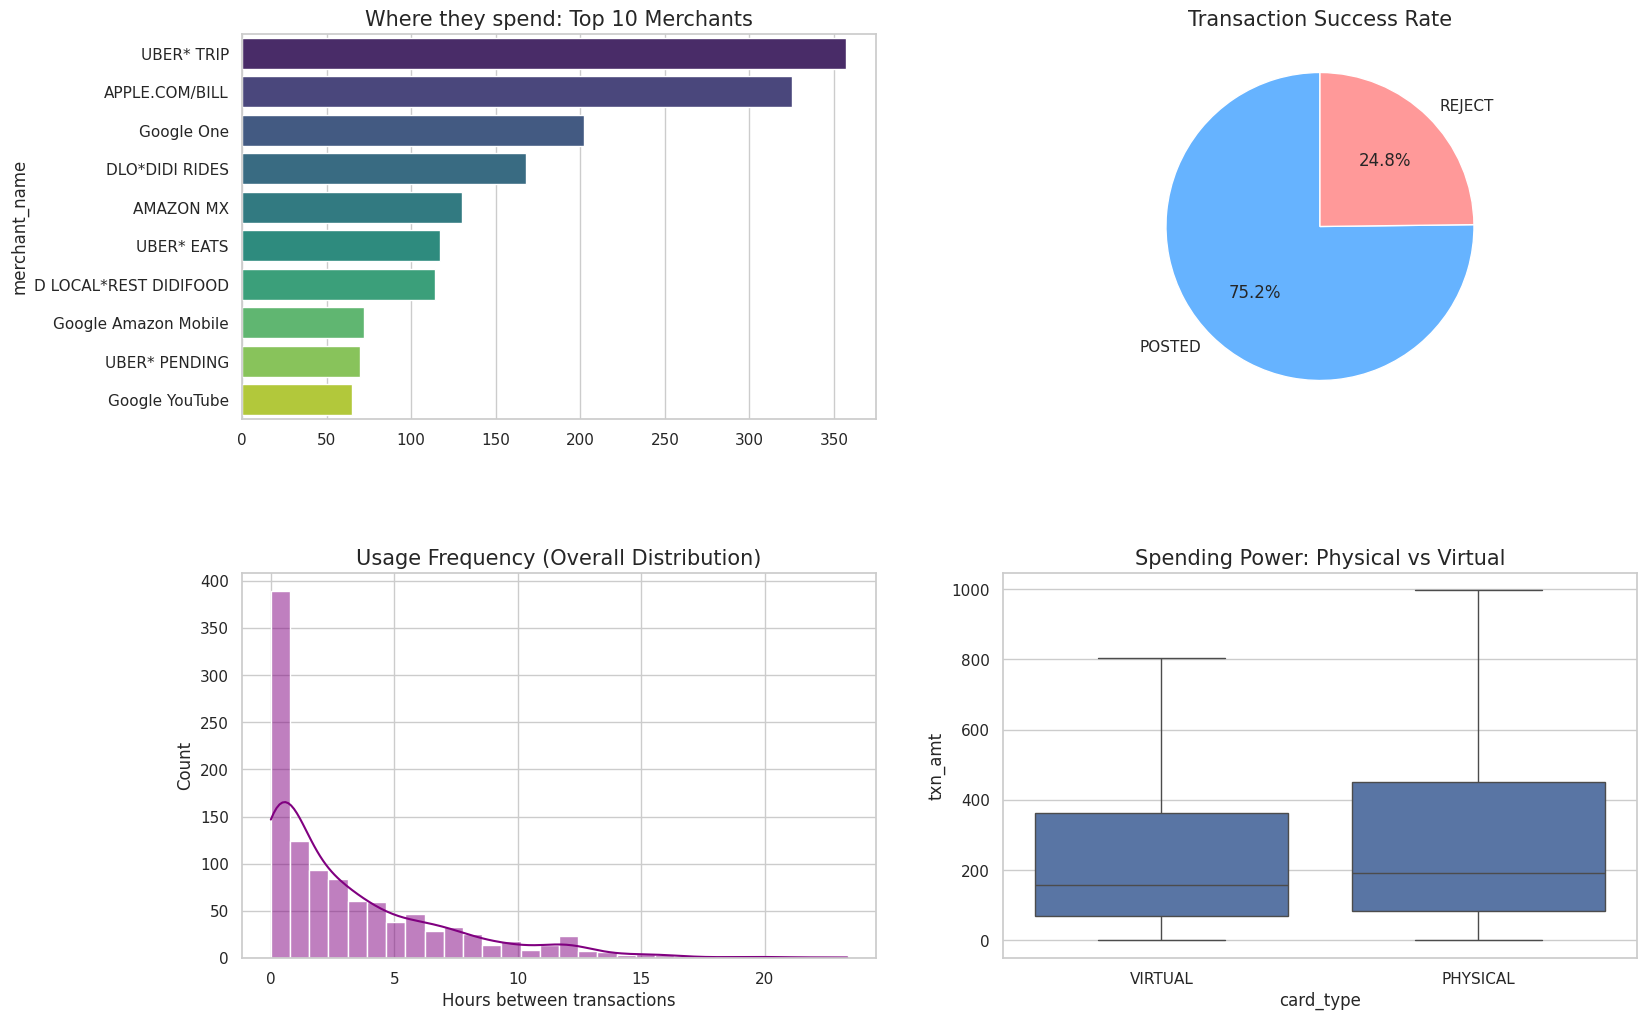

In [ ]:
#Start your visualizations here
# Create a dashboard layout
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
plt.subplots_adjust(hspace=0.4)

# 1. Top Merchants
top_merchants = df_enriched_transactions['merchant_name'].value_counts().head(10)
sns.barplot(x=top_merchants.values, y=top_merchants.index, ax=axes[0,0], palette="viridis")
axes[0,0].set_title('Where they spend: Top 10 Merchants', fontsize=15)

# 2. Status Breakdown
status_counts = df_enriched_transactions['txn_status'].value_counts()
axes[0,1].pie(status_counts, labels=status_counts.index, autopct='%1.1f%%', colors=['#66b3ff','#ff9999'], startangle=90)
axes[0,1].set_title('Transaction Success Rate', fontsize=15)

# 3. Time Between Transactions
sns.histplot(df_enriched_transactions['time_diff_hours'].dropna(), bins=30, ax=axes[1,0], color='purple', kde=True)
axes[1,0].set_title('Usage Frequency (Overall Distribution)', fontsize=15)
axes[1,0].set_xlabel('Hours between transactions')

# 4. Amount Distribution by Card Type
sns.boxplot(x='card_type', y='txn_amt', data=df_enriched_transactions, ax=axes[1,1], showfliers=False)
axes[1,1].set_title('Spending Power: Physical vs Virtual', fontsize=15)

plt.show()

#Summary:

## Data Analysis Key Findings
### 1. **Operational Health & Success Metrics**

- **Transaction Success Rate**: **75.2%** of all transactions were successfully processed and posted.

- **Overall Rejection Rate**: The analysis identified a **24.81%** friction rate, representing the portion of declined transactions.

### 2. **Key Rejection Drivers**

- **Primary Blocker**: The most frequent decline reason is "**The credit line is insufficient**".

- **Impact**: This specific reason accounts for **50.75%** of all rejected transactions.

### 3. **Virtual Card Performance**
- **Average Spending**: The average authorized amount for Virtual Cards is **\$333.12**.

- **Usage Concentration**: The most frequent spending range for approved virtual transactions is between **\$0.90** and **\$444.47**.

- **Behavioral Pattern**: Virtual cards are predominantly used for low-ticket digital services and daily subscriptions.

### 4. **Merchant & Spending Insights**
- **Dominant Merchants**: Spending is heavily concentrated in mobility and digital ecosystems, led by UBER TRIP* and APPLE.COM/BILL.

- **High-Value Outliers**: While the average transaction is low, the analysis detected significant outliers, such as a **\$21,000.00** transaction at "ALMA LOMAS VERDE".

- **Recency**: The latest recorded activity for major retailers like Amazon Mexico was on July 6th, 2025.

### 5. **User Engagement (Time-Series)**
- **Daily Frequency**: Through the time_diff_hours metric, I identified "Power Users" with transactions occurring as close as 7.05 hours apart.

- **Engagement Indicator**: This confirms high card stickiness, where users rely on Stori for multiple daily needs.

### **Insights or Next Steps**

-  Implement a segmentation model to offer immediate line upgrades to users who experience "Insufficient Balance" rejections but have a positive transaction history. This would automatically convert failed transactions into revenue.

- Configure smart push alerts. If a transaction is rejected due to insufficient funds, send a notification prompting the user to make a payment to their card immediately to free up funds and retry the purchase.

- Since the virtual card is used for small and frequent transactions, it is recommended to create loyalty campaigns (cashback or discounts) at top retailers such as Uber or Amazon to ensure that Stori remains "Top of Mind" in the digital ecosystem.

- Introduce a more visible "Available Line" meter on the app's main screen or proximity-to-limit alerts (e.x., "You have 10% of your line left") to reduce the frustration of rejection at the point of sale.

# Step 6. Download the Notebook
Once you’ve completed your analysis, download your notebook by going to:
File → Download → Download .ipynb

Send the downloaded file back to us whenever you feel ready to submit your work.